${\large Oppgave\ 6\ Varmeligning}$


In [ ]:
# kode for plot

#   Denne importen må aktiveres for å kunne kjøre animasjonene i Jupyter notebook/VScode studio
#------
# import matplotlib
# matplotlib.use("TkAgg")
#-------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

alpha = 0.084  # cm^2/min   # Termisk diffusitet av K-virke

m = 15
x = np.linspace(-5, 5, m + 2)
dx = x[1] - x[0]

n = 30
y = np.linspace(0, 5, n + 2)
dy = y[1] - y[0]

nt = 200000  # nt+1 antall t-verdier
t = np.linspace(0, 70, nt + 1)
dt = t[1] - t[0]
dt_maks = (1 / 2 * dx**2) / alpha  # anbefalt maks verdi for dt
print(f"dt burde ikke overskride verdien {dt_maks}.")
print(f"dt sin verdi er {dt}")

#   Uttrykket for temperatur i tverrsnittet
u = np.zeros((nt + 1, m + 2, n + 2))  # u(t,x,y)

#   Initialbetingelse
u[0, 1:-1, 1:-1] = 15  # Grader Celcius

#   Randbetingelser
u[:, :, -1] = 200  # Grader Celcius
u[:, :, 0] = 200  # Grader Celcius
u[:, 0, :] = 200  # Grader Celcius
u[:, -1, :] = 200  # Grader Celcius

# euler
for i in range(nt):
    uxx = 1 / dx**2 * (u[i, :-2, 1:-1] - 2 * u[i, 1:-1, 1:-1] + u[i, 2:, 1:-1])
    uyy = 1 / dx**2 * (u[i, 1:-1, :-2] - 2 * u[i, 1:-1, 1:-1] + u[i, 1:-1, 2:])
    u[i + 1, 1:-1, 1:-1] = u[i, 1:-1, 1:-1] + dt * alpha * (uxx + uyy)

dt burde ikke overskride verdien 2.3251488095238093.
dt sin verdi er 0.00035


C:\Users\Henrik\AppData\Local\Temp\ipykernel_10780\2206887112.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen


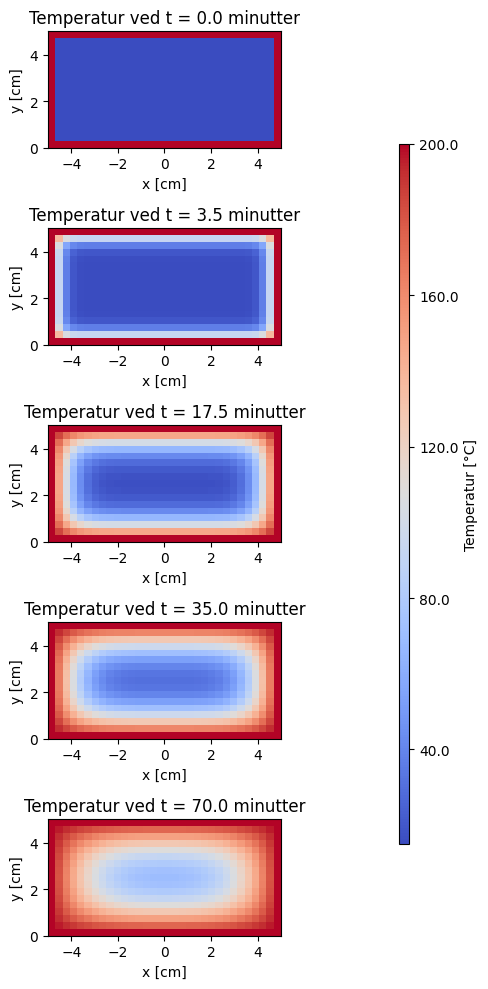

In [ ]:
# Plotting av oppg 6
#
# Velger hvilke tidspunkter som skal plottes
tider = [0, 10000, 50000, 100000, -1]

#   Lager figuren
fig, axs = plt.subplots(len(tider), 1, figsize=(5, 10))

# Setter inn riktige verdier på x- og y-akse
extent = [x.min(), x.max(), y.min(), y.max()]

# Lager plot for de forskjellige tidspunktene
for i, tid in enumerate(tider):
    im = axs[i].imshow(
        u[tid, :, :],
        cmap="coolwarm",
        origin="lower",
        extent=extent,
        aspect="equal",
        vmin=u.min(),
        vmax=u.max(),
    )
    axs[i].set_title(f"Temperatur ved t = {t[tid]:.1f} minutter")
    axs[i].set_xlabel("x [cm]")
    axs[i].set_ylabel("y [cm]")

# Felles fargeskala
# Lager en egen akse for fargeskalaen til høyre
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)

# Ryddigere tallformat
cbar.locator = MaxNLocator(nbins=6)  # maks 6 tick-verdier
cbar.formatter = FormatStrFormatter("%.1f")  # én desimal, ingen eksponent
cbar.update_ticks()
cbar.set_label("Temperatur [°C]")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen
plt.show()


Planken når 60°C i midten etter ca. 61.08 minutter.


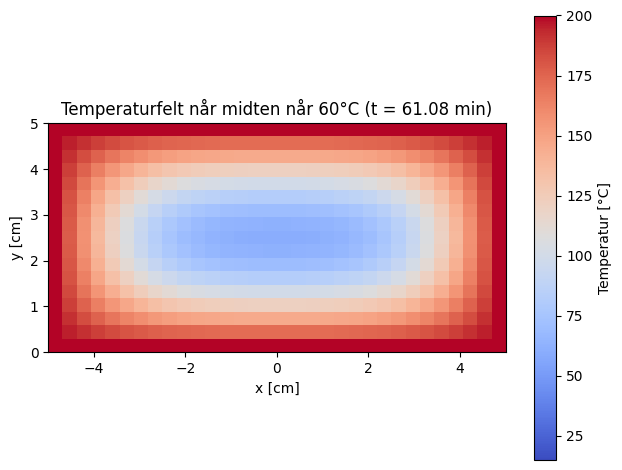

In [ ]:
#
#   C) 
#   Finner tidspunkt for temperatur på 60 grader midt i planken. 
# 

#
#   Finner midtpunkinndeksen til "planken" med luftlag
#
ix_mid = m//2 + 1
iy_mid = n//2 + 1
T_mid = u[:, ix_mid, iy_mid]

# Finn første tidspunkt der temperaturen overstiger 60°C
idx_60 = np.argmax(T_mid >= 60)

# Tilsvarende tid i minutter
tid_60 = t[idx_60]

print(f"Planken når 60°C i midten etter ca. {tid_60:.2f} minutter.")


#   Lager figuren
fig, axs = figsize=(5, 10)

# Setter inn riktige verdier på x- og y-akse
extent = [x.min(), x.max(), y.min(), y.max()]

###

idx = int(idx_60)  # sikre heltallsindeks for indeksering

fig, ax = plt.subplots()

im = ax.imshow(
    u[idx, :, :],
    cmap="coolwarm",
    origin="lower",
    extent=extent,
    aspect="equal",
    vmin=u.min(),   
    vmax=u.max(),   
)

ax.set_title(f"Temperaturfelt når midten når 60°C (t = {tid_60:.2f} min)")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")

# Fargebar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Temperatur [°C]")

plt.tight_layout()
plt.show()

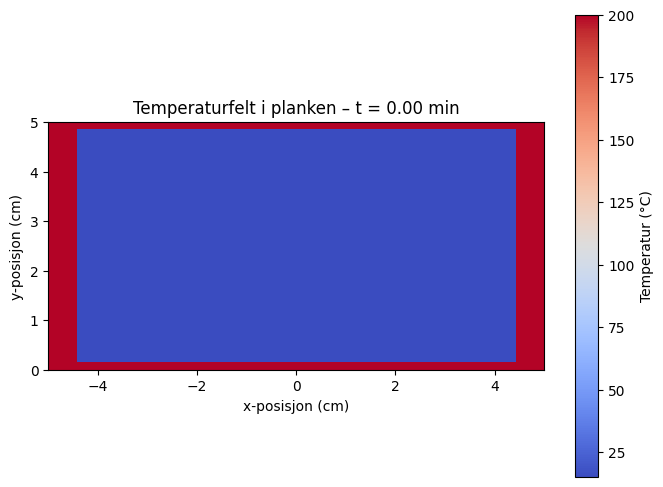

In [ ]:
# 
# D) 
#   Lager en animajson av varmeplottet i oppg. 6
#
# 

import matplotlib.animation as animation

# Velg hvilke tidssteg som skal vises i animasjonen
# (for eksempel hvert 500. tidssteg for å gjøre animasjonen raskere)
step = 500
frames = range(0, nt+1, step)

fig, ax = plt.subplots(figsize=(8, 6))

# Første bilde
heatmap = ax.imshow(
    u[0].T,
    origin="lower",
    cmap="coolwarm",
    extent=[x[0], x[-1], y[0], y[-1]],
    aspect="equal",
    vmin=15, vmax=200
)

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Temperatur (°C)")

ax.set_xlabel("x-posisjon (cm)")
ax.set_ylabel("y-posisjon (cm)")
ax.set_title("Temperaturfelt i planken over tid")

# Oppdateringsfunksjon for animasjonen
def update(frame):
    heatmap.set_data(u[frame].T)
    ax.set_title(f"Temperaturfelt i planken – t = {t[frame]:.2f} min")
    return [heatmap]

# Lag animasjonen
ani = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=20,   # millisekunder mellom frames
    blit=True
)

plt.show()

## Oppgave 7: Luften skal med

In [ ]:
# Kode for plot oppgave 7
# 
# 
alpha_luft = 0.5  # cm^2/min eller 22mm^2/s   # Termisk diffusitet av luft

m_2 = 30
x_2 = np.linspace(-10, 10, m_2 + 2)
dx_2 = x_2[1] - x_2[0]

n_2 = 60
y_2 = np.linspace(-2.5, 7.5, n_2 + 2)
dy_2 = y_2[1] - y_2[0]

#   Uttrykket for temperatur i hele ovnen (med planken)
u_2 = np.zeros((nt + 1, m_2 + 2, n_2 + 2))  # u(t,x,y)

#   Initialbetingelse ytterkant ovn 
u_2[0, 1:-1, 1:-1] = 200  # temperaturen til luften i ovenen

#   Randbetingelser for luften
u_2[:, :, -1] = 200  # Grader Celcius
u_2[:, :, 0] = 200  # Grader Celcius
u_2[:, 0, :] = 200  # Grader Celcius
u_2[:, -1, :] = 200  # Grader Celcius

_, Bx, By = u_2.shape
_, Sx, Sy = u.shape

# Start- og sluttindekser for "planke" inni ovnen
x0 = (Bx - Sx) // 2
x1 = x0 + Sx

y0 = (By - Sy) // 2
y1 = y0 + Sy

#   Må lage initialbetingelse i luft hvor luften møter materialet
u_2[0, x0:x1, y0:y1] = 15 # Luften som ligger i området hvor materialet er
u_2[0, x0:x1, y1] = 15  # Grader Celcius
u_2[0, x0:x1, y0] = 15  # Grader Celcius
u_2[0, x0, y0:y1] = 15  # Grader Celcius
u_2[0, x1, y0:y1] = 15  # Grader Celcius


# euler
for i in range(nt):
    #   Finner verdier for luft i ovnen
    uxx_2 = (
        1 / dx_2**2 * (u_2[i, :-2, 1:-1] - 2 * u_2[i, 1:-1, 1:-1] + u_2[i, 2:, 1:-1])
    )
    uyy_2 = (
        1 / dy_2**2 * (u_2[i, 1:-1, :-2] - 2 * u_2[i, 1:-1, 1:-1] + u_2[i, 1:-1, 2:])
    )
    u_2[i + 1, 1:-1, 1:-1] = u_2[i, 1:-1, 1:-1] + dt * alpha_luft * (uxx_2 + uyy_2)

    #   DIRICLET-BETINGELSE
    #   Legger inn randbetingelse for "planke"
    u[i, :, -1] = u_2[i, x0:x1, y1]  # Grader Celcius
    u[i, :, 0] = u_2[i, x0:x1, y0]  # Grader Celcius
    u[i, 0, :] = u_2[i, x0, y0:y1]  # Grader Celcius
    u[i, -1, :] = u_2[i, x1, y0:y1]  # Grader Celcius

    #   ROBINSON-BETINGELSE
    H = 0.1  # varmeovergang, 1/min
    # toppkant
    # u[i, :, -1] += dt * H * (u_2[i, x0:x1, y1] - u[i, :, -1])
    # bunnkant
    # u[i, :, 0] += dt * H * (u_2[i, x0:x1, y0] - u[i, :, 0])
    # venstrekant
    # u[i, 0, :] += dt * H * (u_2[i, x0, y0:y1] - u[i, 0, :])
    # høyrekant
    # u[i, -1, :] += dt * H * (u_2[i, x1, y0:y1] - u[i, -1, :])

    uxx = 1 / dx**2 * (u[i, :-2, 1:-1] - 2 * u[i, 1:-1, 1:-1] + u[i, 2:, 1:-1])
    uyy = 1 / dy**2 * (u[i, 1:-1, :-2] - 2 * u[i, 1:-1, 1:-1] + u[i, 1:-1, 2:])
    u[i + 1, 1:-1, 1:-1] = u[i, 1:-1, 1:-1] + dt * alpha * (uxx + uyy)

    # Slicing
u_2[:, x0:x1, y0:y1] = u

dt_max = 1 / (2 * alpha_luft * (1/dx_2**2 + 1/dy_2**2))
print("Maks dt for stabilitet:", dt_max)
print(f"{dt =}")


Maks dt for stabilitet: 0.02524455664247402
dt =np.float64(0.00035)


C:\Users\Henrik\AppData\Local\Temp\ipykernel_10780\4091903053.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen


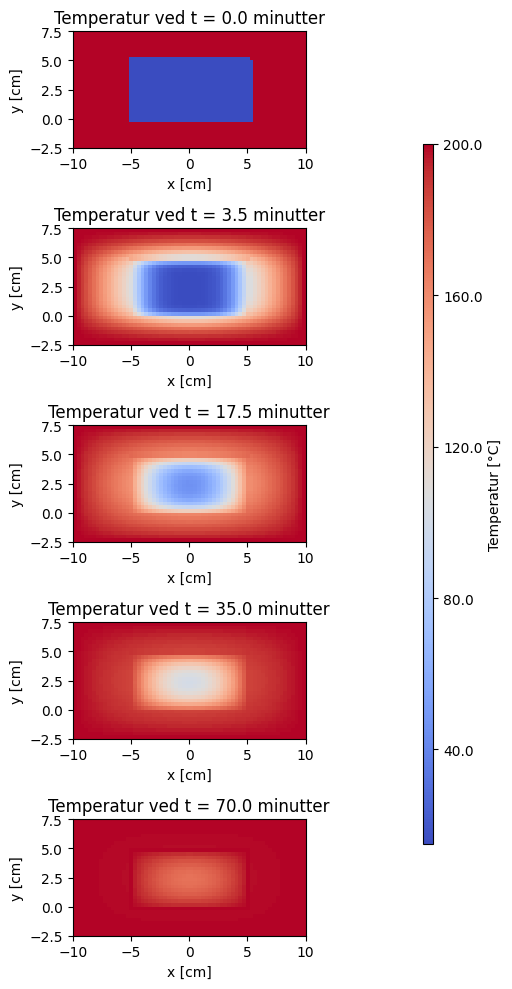

In [ ]:
#
# Plotting av oppg 7

#   Lager figuren
fig, axs = plt.subplots(len(tider), 1, figsize=(5, 10))

# Setter inn riktige verdier på x- og y-akse
extent = [x_2.min(), x_2.max(), y_2.min(), y_2.max()]

# Lager plot for de forskjellige tidspunktene
for i, tid in enumerate(tider):
    im = axs[i].imshow(
        u_2[tid, :, :],
        cmap="coolwarm",
        origin="lower",
        extent=extent,
        aspect="equal",
        vmin=u_2.min(),
        vmax=u_2.max(),
    )
    axs[i].set_title(f"Temperatur ved t = {t[tid]:.1f} minutter")
    axs[i].set_xlabel("x [cm]")
    axs[i].set_ylabel("y [cm]")

# Felles fargeskala
# Lager en egen akse for fargeskalaen til høyre
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)

# Ryddigere tallformat
cbar.locator = MaxNLocator(nbins=6)  # maks 6 tick-verdier
cbar.formatter = FormatStrFormatter("%.1f")  # én desimal, ingen eksponent
cbar.update_ticks()
cbar.set_label("Temperatur [°C]")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen
plt.show()

In [ ]:
#
#   C) 
#   Lager en animasjon av varmeplottet
# 

step = 500
frames = range(0, nt+1, step)

fig, ax = plt.subplots(figsize=(8, 6))

# Første bilde
heatmap = ax.imshow(
    u_2[0].T,
    origin="lower",
    cmap="coolwarm",
    extent=[x_2[0], x_2[-1], y_2[0], y_2[-1]],
    aspect="equal",
    vmin=15, vmax=200
)

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Temperatur (°C)")

ax.set_xlabel("x-posisjon (cm)")
ax.set_ylabel("y-posisjon (cm)")
ax.set_title("Temperaturfelt i planken over tid")

# Oppdateringsfunksjon for animasjonen
def update(frame):
    heatmap.set_data(u_2[frame].T)
    ax.set_title(f"Temperaturfelt i planken – t = {t[frame]:.2f} min")
    return [heatmap]

# Lag animasjonen
ani = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=20,   # millisekunder mellom frames
    blit=True
)

plt.show()

In [ ]:
#
#  
#   Finner midtpunkinndeksen til "planken" med luftlag
#
ix_mid_2 = m_2//2 + 1
iy_mid_2 = n_2//2 + 1
T_mid_2 = u_2[:, ix_mid_2, iy_mid_2]

# Finn første tidspunkt der temperaturen overstiger 60°C
idx_60_2 = np.argmax(T_mid_2 >= 60)

# Tilsvarende tid i minutter
tid_60_2 = t[idx_60_2]

print(f"Planken når 60°C i midten etter ca. {tid_60_2:.2f} minutter.")


#   Lager figuren
fig, axs = figsize=(5, 10)

# Setter inn riktige verdier på x- og y-akse
extent = [x_2.min(), x_2.max(), y_2.min(), y_2.max()]

###

idx = int(idx_60_2)  # sikre heltallsindeks for indeksering

fig, ax = plt.subplots()

im = ax.imshow(
    u_2[idx, :, :],
    cmap="coolwarm",
    origin="lower",
    extent=extent,
    aspect="equal",
    vmin=u_2.min(),   # evt. u_2[idx].min()
    vmax=u_2.max(),   # evt. u_2[idx].max()
)

ax.set_title(f"Temperaturfelt når midten når 60°C (t = {tid_60_2:.2f} min)")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")

# Fargebar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Temperatur [°C]")

plt.tight_layout()
plt.show()



Planken når 60°C i midten etter ca. 21.79 minutter.


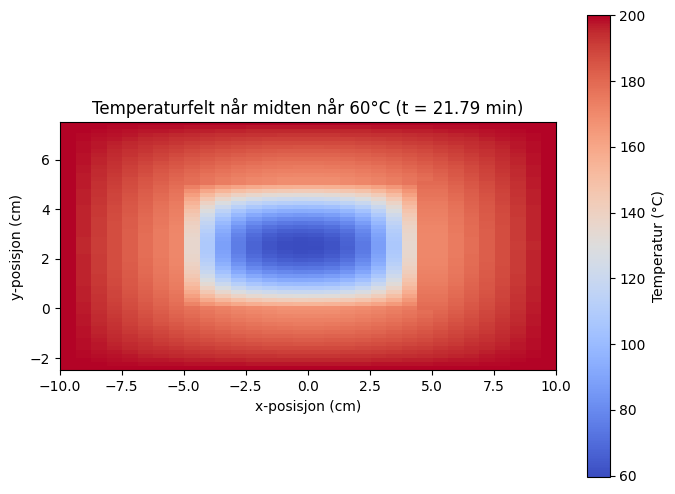

In [ ]:
#   Lager plot for tidspunktet der dette skjer
varmeplot60_luft = u_2[idx_60_2, :, :]

# Plot 2D varmefelt
plt.figure(figsize=(8, 6))
plt.imshow(
    varmeplot60_luft.T,
    origin="lower",
    cmap="coolwarm",
    extent=[x_2[0], x_2[-1], y_2[0], y_2[-1]],
    aspect="equal"
)
plt.colorbar(label="Temperatur (°C)")
plt.title(f"Temperaturfelt når midten når 60°C (t = {tid_60_2:.2f} min)")
plt.xlabel("x-posisjon (cm)")
plt.ylabel("y-posisjon (cm)")
plt.show()